# Streamlines and stagnation points in 2D

A streamline is a line everywhere tangent to the velocity field. In 2D that definition reads:

$$\frac{dy}{dx} = \frac{v}{u}$$

and a stagnation point is a point where the velocity vanishes, $\mathbf{v} = 0$.

## Tasks:

1. Consider the field of Example 4.1 of the textbook, find its stagnation point and integrate the streamlines with ``sympy``.

2. Do the same for the flow past a circular cylinder: obtain 2 stagnation points and a speed map.

3. Relax the steady flow assumption and compare streamlines with pathlines.

Work in SI throughout.

In [81]:
# Import libraries

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

## 1. The velociy field of Example 4.1 (textbook)

$$\mathbf{v} = \frac{v_0}{\ell}\left(-x\,\hat{\imath} + y\,\hat{\jmath}\right)$$

$$\qquad\Longrightarrow\qquad u = -\frac{v_0 x}{\ell}, \quad v = \frac{v_0 y}{\ell}$$

In [82]:
# Constants

v0  = 2.0      # reference speed, m/s
ell = 1.0      # reference length, m

In [83]:
# Velocity components, SI

u_field = lambda x, y: -v0 * x / ell
v_field = lambda x, y:  v0 * y / ell

In [84]:
# Stagnation points: solve u = 0 and v = 0

x, y = sp.symbols('x y', real=True)

u_sym = -v0 * x / ell
v_sym =  v0 * y / ell

stag = sp.solve([u_sym, v_sym], [x, y], dict=True)

display("stagnation points:", stag)

'stagnation points:'

[{x: 0.0, y: 0.0}]

In [85]:
# Streamlines: integrate dy/dx = v/u

f = sp.Function('y')

ode = sp.Eq(f(x).diff(x), (v0 * f(x) / ell) / (-v0 * x / ell))

sol = sp.dsolve(ode)

display("The streamline equations are:", sol)

'The streamline equations are:'

Eq(y(x), C1/x)

## Streamlines:
So $y = C/x$, that is $xy = C$: the streamlines are rectangular hyperbolae.

In [86]:
# Grid in m

xg = np.linspace(-3, 3, 300)
yg = np.linspace(-3, 3, 300)

# Meshgrid
x_2d, y_2d = np.meshgrid(xg, yg)

# V field
U = u_field(x_2d, y_2d)
V = v_field(x_2d, y_2d)

# Speed in m/s
speed = np.sqrt(U**2 + V**2)

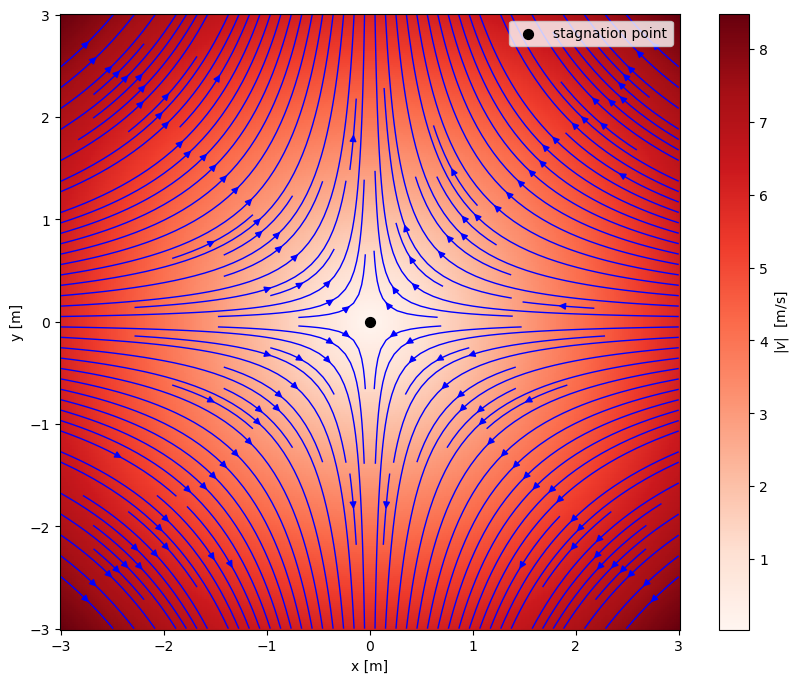

In [87]:
plt.figure(figsize=(10, 8))

z = plt.pcolormesh(x_2d, y_2d, speed, cmap="Reds")

plt.streamplot(x_2d, y_2d, U, V, color="b", density=2., linewidth=1.0)

plt.scatter(0, 0, s=50, color="k", label="stagnation point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")

plt.colorbar(z, label="$|v|$  [m/s]")
plt.legend(loc= 1)

plt.show()

### Observations:

- The flow comes in along $x$ and leaves along $y$, and the only point where both components vanish is the origin, $O$.

- The speed grows linearly with the distance from the stagnation point.

- The streamlines are the curves $xy = C$.

## 2. Flow past a circular cylinder

A uniform stream of speed $v_\infty$ past a cylinder of radius $a$ gives

$$u = v_\infty\left[1 - a^2\,\frac{x^2 - y^2}{(x^2+y^2)^2}\right]$$

$$\qquad v = -\,v_\infty\,\frac{2a^2xy}{(x^2+y^2)^2}$$

This is the flow behind the stagnation point.

#### Reference: Munson book, 6.6.3 Flow around a Circular Cylinder 

In [88]:
# Constants

v_inf = 1.0     # free stream speed, m/s
a     = 1.0     # cylinder radius, m

In [89]:
# Velocity components, SI

def cylinder(x, y):
    """Velocity field in Cartersian coordinates"""

    r2 = x**2 + y**2

    u = v_inf * (1.0 - a**2 * (x**2 - y**2) / r2**2)

    v = -v_inf * 2.0 * a**2 * x * y / r2**2

    return u, v

In [90]:
# Stagnation points: same method as before

u_sym, v_sym = cylinder(x, y)

stag = sp.solve([u_sym, v_sym], [x, y], dict=True)

display("Stagnation points are at:\n", stag)

'Stagnation points are at:\n'

[{x: -1.00000000000000, y: 0.0}, {x: 1.00000000000000, y: 0.0}]

In [91]:
# Grid in m

xg = np.linspace(-3, 3, 600)
yg = np.linspace(-2, 2, 400)

# Mesgrid
x_2d, y_2d = np.meshgrid(xg, yg)

# Velocity field
U, V = cylinder(x_2d, y_2d)

# Blank out the inside of the cylinder
inside = x_2d**2 + y_2d**2 < a**2

U[inside] = np.nan
V[inside] = np.nan

# Speed
speed = np.sqrt(U**2 + V**2)

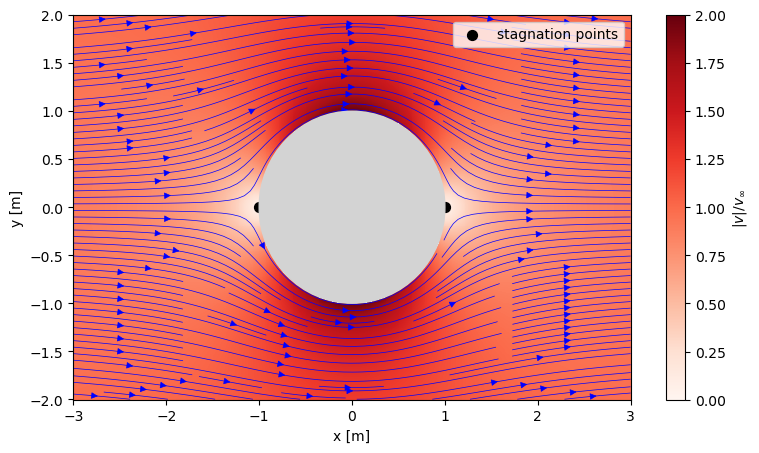

In [92]:
plt.figure(figsize=(9, 5))

z = plt.pcolormesh(x_2d, y_2d, speed / v_inf, cmap="Reds", vmin=0, vmax=2)

plt.streamplot(x_2d, y_2d, U, V, color="b", density=2., linewidth=0.5)

plt.gca().add_patch(plt.Circle((0, 0), a, color="lightgray", zorder=4))

plt.scatter([-a, a], [0, 0], s=50, color="k", label="stagnation points")

plt.xlabel("x [m]")
plt.ylabel("y [m]")

plt.colorbar(z, label=r"$|v| / v_\infty$")
plt.legend(loc=1)

plt.show()

## Speed on the surface of the cylinder: 

$$|v| = 2 v_{\rm inf} |\sin(\theta)|$$

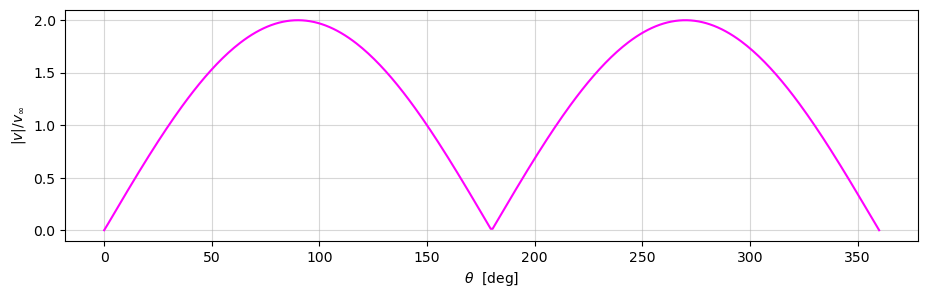

In [93]:
# Speed on the surface of the cylinder: |v| = 2 v_inf |sin(theta)|

theta = np.linspace(0, 2*np.pi, 400)

# Velocity coordinates
u_s, v_s = cylinder(a*np.cos(theta)*1.001, a*np.sin(theta)*1.001)


plt.figure(figsize=(11, 3))

plt.plot(np.degrees(theta), np.sqrt(u_s**2 + v_s**2) / v_inf, color="magenta")

plt.xlabel(r"$\theta$  [deg]")
plt.ylabel(r"$|v| / v_\infty$")

plt.grid(alpha=0.5)

plt.show()

### Observations:

- There are 2 stagnation points, at the nose and at the tail, $(\pm a, 0)$.

- On the shoulders, $\theta = 90^\circ$ and $270^\circ$, the speed reaches $2\,v_\infty$: the fluid has to go around.

- This plot is also a pressure plot upside down (Bernoulli).

## 3. Relaxing steadiness: the oscillating slit

For steady flow, a **streamline** is also the **path a particle takes**. Here we study unsteady effects, which are among the restrictions on using the Bernoulli equation. 

Water leaves a slit that swings from side to side, so that:

$$\mathbf{v} = u_0\sin\left[\omega\left(t - \frac{y}{v_0}\right)\right]\hat{\imath} + v_0\,\hat{\jmath}$$

The flow is unsteady, so the streamlines are redrawn at every instant while a particle keeps going along its own path.

#### Reference: Example 4.3 in Munson's book

In [94]:
# Constants

u0    = 1.0              # amplitude of the transverse velocity, m/s
vy    = 1.0              # constant vertical velocity, m/s
omega = 2.0 * np.pi      # angular frequency, rad/s

In [95]:
# Velocity components, SI

def slit(x, y, t):
    u = u0 * np.sin(omega * (t - y / vy))
    v = vy * np.ones_like(x)
    return u, v

In [96]:
# Grid in m

xg = np.linspace(-1.0, 1.0, 200)
yg = np.linspace( 0.0, 2.0, 200)

x_2d, y_2d = np.meshgrid(xg, yg)

# Two instants, a quarter of a period apart
times = [0.0, 0.25]

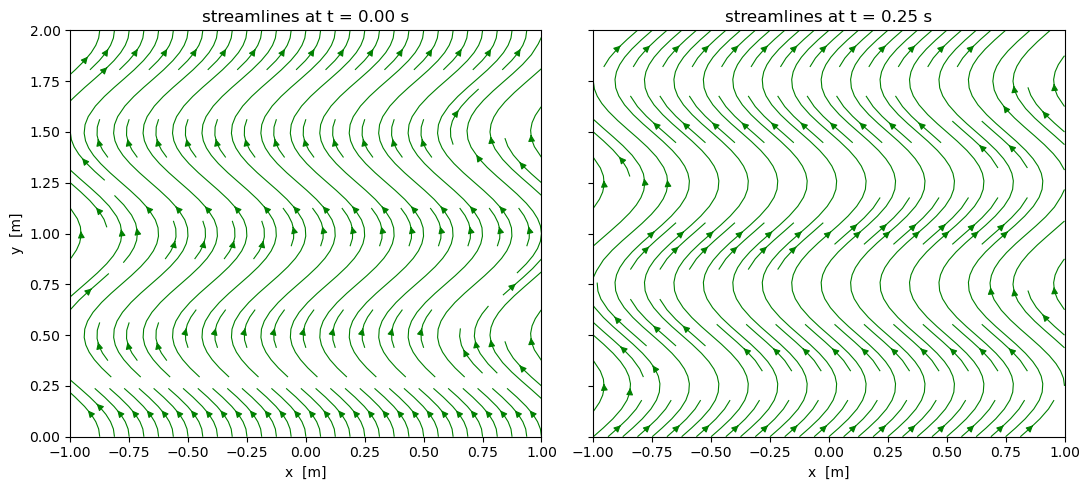

In [97]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, t in zip(axs, times):
    U, V = slit(x_2d, y_2d, t)
    ax.streamplot(x_2d, y_2d, U, V, color="g", density=1.1, linewidth=0.8)
    ax.set_xlabel("x  [m]")
    ax.set_title(f"streamlines at t = {t:.2f} s")

axs[0].set_ylabel("y  [m]")

plt.tight_layout()

plt.show()

In [98]:
# Pathlines: release particles at the origin at different times and follow them

def pathline(t_release, t_end=2.0, dt=1e-3):
    n = int(t_end / dt)
    x_p, y_p = 0.0, 0.0
    xs, ys = [x_p], [y_p]
    for i in range(n):
        t = t_release + i * dt
        u = u0 * np.sin(omega * (t - y_p / vy))
        x_p = x_p + u * dt
        y_p = y_p + vy * dt
        xs.append(x_p)
        ys.append(y_p)
    return np.array(xs), np.array(ys)

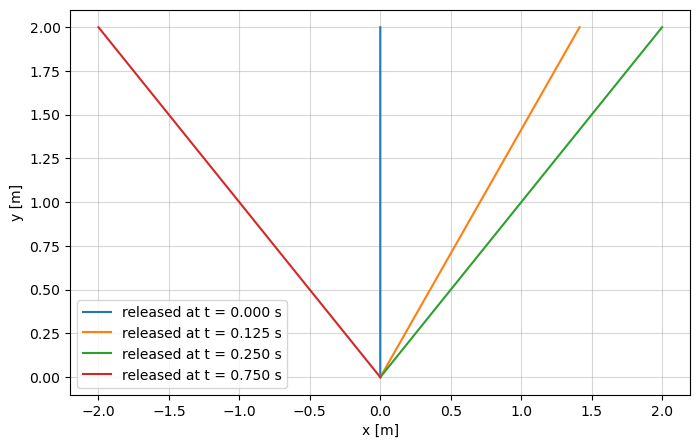

In [100]:
plt.figure(figsize=(8, 5))

for t_release in [0.000, 0.125, 0.250, 0.750]:
    xs, ys = pathline(t_release)
    plt.plot(xs, ys, label=f"released at t = {t_release:.3f} s")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.grid(alpha=0.5)
plt.legend()

plt.show()

### Observations:

- The 2 streamline plots are different pictures of the same flow taken a quarter of a period apart: with an unsteady field the pattern is redrawn at every instant.

- The pathlines are straight rays from the origin, and each particle gets its own ray: along a path $t - y/v_0$ stays equal to the release time, so $u$ never changes and the slope is fixed at $v_0 / [u_0\sin(\omega t_{\rm release})]$.

- The two plots above show different things:

 - The streamlines are the pattern frozen at one instant
 - The pathlines are the track each particle actually follows. Here they disagree.

- A third line, the **streakline**, is what a photograph would show: dye injected continuously at the origin. It is different again, and it changes with time as well.

- Now set $\omega = 0$, so the slit stops moving. Then $u = 0$ everywhere and the streamline, the pathline and the streakline through any given point are all the same vertical line. That is the steady case, and it is the one the Bernoulli equation of Lecture 6 assumes.